In [1]:
import pandas as pd

df = pd.read_csv(r'C:\Users\angel\DS8_SIA\DS8_SIA_Project\project\01_data\satellite\satellite_data.csv')

In [2]:
print(df.shape)
print(df.dtypes)
print(df.head())

(161, 17)
OBJECT_NAME             object
OBJECT_ID               object
EPOCH                   object
MEAN_MOTION            float64
ECCENTRICITY           float64
INCLINATION            float64
RA_OF_ASC_NODE         float64
ARG_OF_PERICENTER      float64
MEAN_ANOMALY           float64
EPHEMERIS_TYPE           int64
CLASSIFICATION_TYPE     object
NORAD_CAT_ID             int64
ELEMENT_SET_NO           int64
REV_AT_EPOCH             int64
BSTAR                  float64
MEAN_MOTION_DOT        float64
MEAN_MOTION_DDOT         int64
dtype: object
          OBJECT_NAME  OBJECT_ID                       EPOCH  MEAN_MOTION  \
0               SCD 1  1993-009B  2026-04-22T12:49:28.295328    14.460946   
1  TECHSAT 1B (GO-32)  1998-043D  2026-04-22T17:06:16.872192    14.244169   
2               SCD 2  1998-060A  2026-04-22T12:56:21.234624    14.455037   
3          DLR-TUBSAT  1999-029B  2026-04-22T11:48:27.351072    14.524117   
4               TERRA  1999-068A  2026-04-22T19:40:36.850080    

In [3]:
# 기본 통계
print(df.describe())

       MEAN_MOTION  ECCENTRICITY  INCLINATION  RA_OF_ASC_NODE  \
count   161.000000    161.000000   161.000000      161.000000   
mean     14.676866      0.000792    93.645542      180.998688   
std       1.196598      0.001239    16.043964       78.220447   
min       1.002689      0.000063     0.365000        2.066500   
25%      14.571175      0.000142    97.434800      120.698000   
50%      14.799420      0.000318    97.888500      179.966500   
75%      15.191495      0.001023    98.185600      242.322600   
max      15.550162      0.011003   100.763800      358.429200   

       ARG_OF_PERICENTER  MEAN_ANOMALY  EPHEMERIS_TYPE  NORAD_CAT_ID  \
count         161.000000    161.000000           161.0    161.000000   
mean          138.789707    218.074111             0.0  42278.105590   
std            94.596038     96.479023             0.0   9744.118597   
min             1.822500      1.377100             0.0  22490.000000   
25%            81.644700    147.070000             0.0

- MEAN_MOTION 평균 14.67 rev/day → 대부분 저궤도(LEO) 위성
- ECCENTRICITY 매우 작음 (평균 0.0008) → 거의 다 원형 궤도
- INCLINATION 평균 93.6° → 대부분 태양동기궤도(SSO) 위성
- EPHEMERIS_TYPE 전부 0, ELEMENT_SET_NO 전부 999 → 상수값이라 분석 의미 없음
- MEAN_MOTION_DDOT 전부 0 → 이 컬럼 삭제해도 됨

In [4]:
# 위성 이름 전체 확인
print(df['OBJECT_NAME'].values)

['SCD 1' 'TECHSAT 1B (GO-32)' 'SCD 2' 'DLR-TUBSAT' 'TERRA' 'MAROC-TUBSAT'
 'AQUA' 'SHIYAN-1 (SY-1)' 'AURA' 'IRS-P5 (CARTOSAT-1)' 'SINAH 1'
 'RESURS-DK 1' 'ARIRANG-2 (KOMPSAT-2)' 'LAPAN-TUBSAT' 'HAIYANG-1B'
 'COSMO-SKYMED 1' 'TERRASAR-X' 'WORLDVIEW-1 (WV-1)' 'YAOGAN-3'
 'COSMO-SKYMED 2' 'RADARSAT-2' 'CARTOSAT-2A' 'HUANJING 1A (HJ-1A)'
 'HUANJING 1B (HJ-1B)' 'GEOEYE 1' 'THEOS' 'COSMO-SKYMED 3' 'YAOGAN-4'
 'GOSAT (IBUKI)' 'DEIMOS-1' 'DUBAISAT-1' 'OCEANSAT-2' 'WORLDVIEW-2 (WV-2)'
 'SMOS' 'YAOGAN-7' 'TANDEM-X' 'CARTOSAT-2B' 'YAOGAN-10' 'COSMO-SKYMED 4'
 'RESOURCESAT-2' 'HAIYANG-2A' 'RASAT' 'SRMSAT' 'PLEIADES 1A'
 'ZIYUAN 1-02C (ZY 1-02C)' 'ARIRANG-3 (KOMPSAT-3)' 'EXACTVIEW-1 (ADS-1B)'
 'SPOT 6' 'PLEIADES 1B' 'GOKTURK 2' 'LANDSAT 8' 'SARAL' 'GAOFEN-1'
 'VNREDSAT 1' 'ARIRANG-5 (KOMPSAT-5)' 'SKYSAT-A' 'DUBAISAT-2' 'GPM-CORE'
 'SENTINEL-1A' 'KAZEOSAT 1' 'ALOS-2' 'KAZEOSAT 2' 'HODOYOSHI-4' 'DEIMOS-2'
 'HODOYOSHI-3' 'SPOT 7' 'SKYSAT-B' 'WORLDVIEW-3 (WV-3)' 'GAOFEN-2'
 'YAOGAN-21' 'YAOGAN-22' 'ASN

- 클로드 코드 결과
    - 우리가 원하는 EO/SAR 상업위성들이 많이 포함되어 있어요!
    - EO: WORLDVIEW, GEOEYE, PLEIADES, SKYSAT, SENTINEL-2, LANDSAT, SPOT, KOMPSAT 등
    - SAR: COSMO-SKYMED, TERRASAR-X, RADARSAT-2, ALOS-2, SENTINEL-1 등

In [5]:
# CLASSIFICATION_TYPE 분포 (U=미분류, C=기밀, S=비밀)
print(df['CLASSIFICATION_TYPE'].value_counts())

CLASSIFICATION_TYPE
U    161
Name: count, dtype: int64


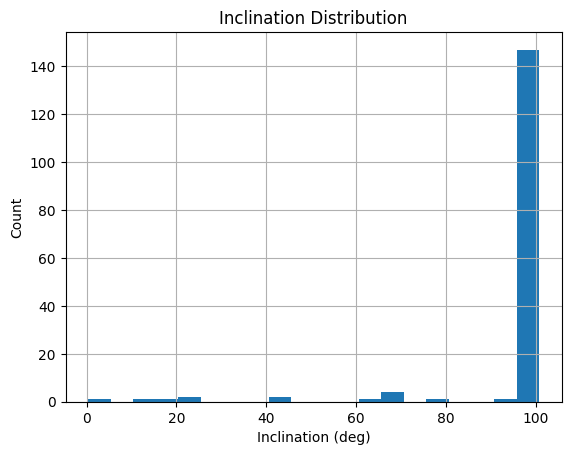

In [6]:
# INCLINATION 분포 확인
import matplotlib.pyplot as plt

df['INCLINATION'].hist(bins=20)
plt.title('Inclination Distribution')
plt.xlabel('Inclination (deg)')
plt.ylabel('Count')
plt.show()

- 90~100° 에 집중 → 태양동기궤도(SSO) 위성이 압도적으로 많음
- SSO는 지구관측 위성의 전형적인 궤도임..
- 나머지 소수는 ISS 궤도(51.6°), 적도 궤도 등

In [7]:
# 결측치 확인
print(df.isnull().sum())

OBJECT_NAME            0
OBJECT_ID              0
EPOCH                  0
MEAN_MOTION            0
ECCENTRICITY           0
INCLINATION            0
RA_OF_ASC_NODE         0
ARG_OF_PERICENTER      0
MEAN_ANOMALY           0
EPHEMERIS_TYPE         0
CLASSIFICATION_TYPE    0
NORAD_CAT_ID           0
ELEMENT_SET_NO         0
REV_AT_EPOCH           0
BSTAR                  0
MEAN_MOTION_DOT        0
MEAN_MOTION_DDOT       0
dtype: int64


In [8]:
# 상수 컬럼 확인 (분석 의미 없는 컬럼)
print(df.nunique().sort_values())

CLASSIFICATION_TYPE      1
ELEMENT_SET_NO           1
EPHEMERIS_TYPE           1
MEAN_MOTION_DDOT         1
BSTAR                  144
MEAN_MOTION_DOT        154
REV_AT_EPOCH           155
INCLINATION            159
ECCENTRICITY           160
ARG_OF_PERICENTER      161
EPOCH                  161
RA_OF_ASC_NODE         161
OBJECT_ID              161
OBJECT_NAME            161
NORAD_CAT_ID           161
MEAN_MOTION            161
MEAN_ANOMALY           161
dtype: int64


- CLASSIFICATION_TYPE ->전부 'U' → 삭제 가능
- ELEMENT_SET_NO -> 전부 999 → 삭제 가능
- EPHEMERIS_TYPE -> 전부 0 → 삭제 가능
- MEAN_MOTION_DDOT -> 전부 0 → 삭제 가능
- BSTAR: 144 -> 대기 항력 계수, 유효한 값
- MEAN_MOTION_DOT: 154 -> 궤도 변화율, 유효한 값

In [9]:
df['EPOCH'] = pd.to_datetime(df['EPOCH'])
print(df['EPOCH'].dtype)
print(df['EPOCH'].head())

datetime64[ns]
0   2026-04-22 12:49:28.295328
1   2026-04-22 17:06:16.872192
2   2026-04-22 12:56:21.234624
3   2026-04-22 11:48:27.351072
4   2026-04-22 19:40:36.850080
Name: EPOCH, dtype: datetime64[ns]


### 고도 계산

In [10]:
import numpy as np

mu = 398600.4418  # 지구 중력 상수 (km^3/s^2)
Re = 6371.0       # 지구 반지름 (km)

# 궤도 주기 (초)
df['T'] = 86400 / df['MEAN_MOTION']

# 반장축 (km)
df['SEMI_MAJOR_AXIS'] = (mu * (df['T'] / (2 * np.pi))**2) ** (1/3)

# 고도 (km)
df['ALTITUDE'] = df['SEMI_MAJOR_AXIS'] - Re

print(df[['OBJECT_NAME', 'MEAN_MOTION', 'ALTITUDE']].to_string())

                 OBJECT_NAME  MEAN_MOTION      ALTITUDE
0                      SCD 1    14.460946    745.569622
1         TECHSAT 1B (GO-32)    14.244169    817.590822
2                      SCD 2    14.455037    747.508891
3                 DLR-TUBSAT    14.524117    724.919588
4                      TERRA    14.610573    696.899077
5               MAROC-TUBSAT    13.702600   1005.774632
6                       AQUA    14.620681    693.641119
7            SHIYAN-1 (SY-1)    15.322997    476.089996
8                       AURA    14.612398    696.310647
9        IRS-P5 (CARTOSAT-1)    14.909014    602.260425
10                   SINAH 1    14.641176    687.046682
11               RESURS-DK 1    15.129699    534.285530
12     ARIRANG-2 (KOMPSAT-2)    14.646234    685.421594
13              LAPAN-TUBSAT    14.858931    617.921098
14                HAIYANG-1B    14.310125    795.485290
15            COSMO-SKYMED 1    14.968220    583.860202
16                TERRASAR-X    15.191495    515

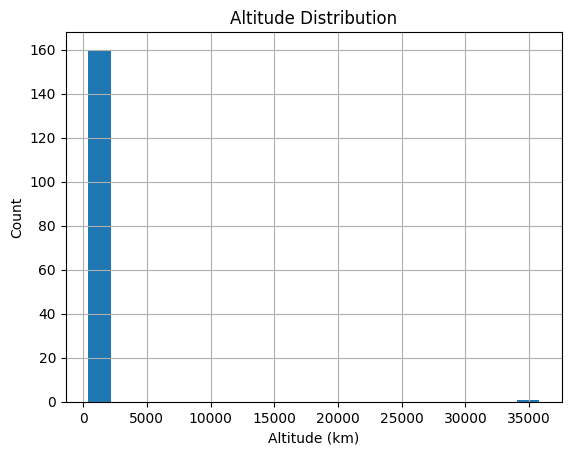

In [11]:
# 고도 분포 시각화
df['ALTITUDE'].hist(bins=20)
plt.title('Altitude Distribution')
plt.xlabel('Altitude (km)')
plt.ylabel('Count')
plt.show()

- 고도 분포
    - 대부분 500 ~ 1000 km 저궤도 (LEO)임. (지구관측 위성답게 낮은 궤도임)
    - 오른쪽 끝 이상치: 35,000km 근처 -> GEO(정지궤도) 위성이 1~2개 섞여 있음

- TERRASAR-X: 515km ✅ SAR 위성
- WORLDVIEW-1: 500km ✅ EO 상업위성
- COSMO-SKYMED 1/2: 583~629km ✅ SAR 위성
- RADARSAT-2: 798km ✅ SAR 위성
- SENTINEL-6B: 1344km → 해양 고도 측정용, 지구관측과 다소 다름

In [12]:
# 고도 이상치 확인 (GEO 위성 등)
print(df[df['ALTITUDE'] > 5000][['OBJECT_NAME', 'ALTITUDE']])

   OBJECT_NAME      ALTITUDE
85    GAOFEN-4  35794.536826


- 딱 한개만 이상치임
- GAOFEN-4 딱 1개만 35,794km → GEO(정지궤도) 위성
- 지구관측용이긴 하지만 정지궤도라 해상도가 낮음
- EO/SAR 분석 시 제외 대상 고려

In [13]:
# 고도 기본 통계
print(df['ALTITUDE'].describe())

count      161.000000
mean       871.442131
std       2774.599470
min        409.242495
25%        515.546771
50%        636.644339
75%        709.633636
max      35794.536826
Name: ALTITUDE, dtype: float64


### Space Eye - T 위성 검색

In [16]:
# Space Eye-T 위성 검색
print(df[df['OBJECT_NAME'].str.contains('SPACE', case=False)])
print(df[df['OBJECT_NAME'].str.contains('EYE', case=False)])
print(df[df['OBJECT_NAME'].str.contains('SIA', case=False)])

Empty DataFrame
Columns: [OBJECT_NAME, OBJECT_ID, EPOCH, MEAN_MOTION, ECCENTRICITY, INCLINATION, RA_OF_ASC_NODE, ARG_OF_PERICENTER, MEAN_ANOMALY, EPHEMERIS_TYPE, CLASSIFICATION_TYPE, NORAD_CAT_ID, ELEMENT_SET_NO, REV_AT_EPOCH, BSTAR, MEAN_MOTION_DOT, MEAN_MOTION_DDOT, T, SEMI_MAJOR_AXIS, ALTITUDE]
Index: []
   OBJECT_NAME  OBJECT_ID                      EPOCH  MEAN_MOTION  \
24    GEOEYE 1  2008-042A 2026-04-22 17:58:37.843968    14.646717   

    ECCENTRICITY  INCLINATION  RA_OF_ASC_NODE  ARG_OF_PERICENTER  \
24      0.000325      98.1252        187.3796           220.9786   

    MEAN_ANOMALY  EPHEMERIS_TYPE CLASSIFICATION_TYPE  NORAD_CAT_ID  \
24      139.1173               0                   U         33331   

    ELEMENT_SET_NO  REV_AT_EPOCH     BSTAR  MEAN_MOTION_DOT  MEAN_MOTION_DDOT  \
24             999         94203  0.000064         0.000003                 0   

              T  SEMI_MAJOR_AXIS    ALTITUDE  
24  5898.932939      7056.266676  685.266676  
Empty DataFrame
C

- 요 데이터엔 없음!

# Celestrack - Activate 

In [17]:
data = pd.read_csv(r"C:\Users\angel\DS8_SIA\DS8_SIA_Project\project\01_data\satellite\celestrack_activate.csv")

In [18]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15448 entries, 0 to 15447
Data columns (total 17 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   OBJECT_NAME          15448 non-null  object 
 1   OBJECT_ID            15448 non-null  object 
 2   EPOCH                15448 non-null  object 
 3   MEAN_MOTION          15448 non-null  float64
 4   ECCENTRICITY         15448 non-null  float64
 5   INCLINATION          15448 non-null  float64
 6   RA_OF_ASC_NODE       15448 non-null  float64
 7   ARG_OF_PERICENTER    15448 non-null  float64
 8   MEAN_ANOMALY         15448 non-null  float64
 9   EPHEMERIS_TYPE       15448 non-null  int64  
 10  CLASSIFICATION_TYPE  15448 non-null  object 
 11  NORAD_CAT_ID         15448 non-null  int64  
 12  ELEMENT_SET_NO       15448 non-null  int64  
 13  REV_AT_EPOCH         15448 non-null  int64  
 14  BSTAR                15448 non-null  float64
 15  MEAN_MOTION_DOT      15448 non-null 

In [19]:
data.head(3)

,OBJECT_NAME,OBJECT_ID,EPOCH,MEAN_MOTION,ECCENTRICITY,INCLINATION,RA_OF_ASC_NODE,ARG_OF_PERICENTER,MEAN_ANOMALY,EPHEMERIS_TYPE,CLASSIFICATION_TYPE,NORAD_CAT_ID,ELEMENT_SET_NO,REV_AT_EPOCH,BSTAR,MEAN_MOTION_DOT,MEAN_MOTION_DDOT
0,CALSPHERE 1,1964-063C,2026-05-20T18:10:54.567264,13.765894,0.002754,90.2234,71.1238,20.3579,12.1178,0,U,900,999,6765,0.000484,4.850000e-06,0.0
1,CALSPHERE 2,1964-063E,2026-05-20T19:23:39.879744,13.528978,0.001707,90.2369,75.1358,311.4700,80.5259,0,U,902,999,85256,0.000074,5.800000e-07,0.0
2,LCS 1,1965-034C,2026-05-20T16:56:21.232320,9.893104,0.001271,32.1404,242.2815,23.4432,336.6644,0,U,1361,999,20716,0.001779,2.200000e-07,0.0


In [23]:
# Space Eye-T 검색
keywords = ['SPACEEYE']
for kw in keywords:
    result = data[data['OBJECT_NAME'].str.contains(kw, case=False)]
    if len(result) > 0:
        print(f"[{kw}] 검색 결과:")
        print(result[['OBJECT_NAME', 'OBJECT_ID', 'ALTITUDE' if 'ALTITUDE' in data.columns else 'MEAN_MOTION']])
    else:
        print(f"[{kw}] 검색 결과 없음")

[SPACEEYE] 검색 결과:
       OBJECT_NAME  OBJECT_ID  MEAN_MOTION
10097  SPACEEYE-T1  2025-052V    15.222148


In [24]:
spaceeye = data[data['OBJECT_NAME'].str.contains('SPACEEYE', case=False)]
print(spaceeye.to_string())

       OBJECT_NAME  OBJECT_ID                       EPOCH  MEAN_MOTION  ECCENTRICITY  INCLINATION  RA_OF_ASC_NODE  ARG_OF_PERICENTER  MEAN_ANOMALY  EPHEMERIS_TYPE CLASSIFICATION_TYPE  NORAD_CAT_ID  ELEMENT_SET_NO  REV_AT_EPOCH     BSTAR  MEAN_MOTION_DOT  MEAN_MOTION_DDOT
10097  SPACEEYE-T1  2025-052V  2026-05-20T23:37:41.182752    15.222148      0.000315      97.3976          33.968           233.0433      127.0515               0                   U         63229             999          6570  0.000147         0.000033               0.0
